# 텍스트 프롬프트 제로샷 분류 (live 텍스트 → 유사도)

PE는 CLIP 계열이라 **이미지 임베딩 ↔ 텍스트 임베딩의 코사인 유사도**로 분류한다.
이 노트북은 **임의 텍스트 문자열을 직접 인코딩**해서(미리 만든 파일이 아니라) 분류한다:

```
image  --(NPU hybrid)----------> (1024) ─┐
"a fire", "smoke", ...                   ├─ cosine → 최고 클래스
        --(PE 텍스트 인코더, CPU)--> (N,1024) ┘
```
- 이미지 = **NPU**(MXQ hybrid), 텍스트 = **PE 텍스트 인코더(CPU)** 로 즉석 인코딩.
- 토크나이저 = CLIP BPE (`open_clip`) — 공식 `perception_models`의 `SimpleTokenizer`와 동일(검증됨).
- 이미지 정규화 0.5/0.5 = 공식 PE transform과 동일. 커널: `pe_npu_host`.
> 운영(`pe_npu`/`pe_binary`)은 같은 원리지만 프롬프트를 미리 인코딩(`text_features.json`)해 속도를 높인다.

In [4]:
import os, sys, glob
import numpy as np, torch
import matplotlib.pyplot as plt
from PIL import Image
import open_clip
sys.path.insert(0, os.path.abspath(".."))
import pe_npu
from pe_npu import load_pe, preprocess_image

# 이미지=NPU, 텍스트=PE 텍스트 인코더(CPU)
npu = pe_npu.MXQInferenceHybrid.from_hf()                 # 이미지 임베딩 (NPU)
clip = load_pe("PE-Core-L14-336", mode="clip", patch=False)  # 텍스트 타워 (CPU)
tokenizer = open_clip.get_tokenizer("ViT-L-14")          # CLIP BPE = PE SimpleTokenizer
ctx = clip.context_length
print("로드 완료 — 이미지:NPU, 텍스트:PE(CPU)")

def encode_text(prompts):
    with torch.no_grad():
        return clip.encode_text(tokenizer(prompts, context_length=ctx), normalize=True)
def encode_image_npu(path):
    e = torch.from_numpy(np.asarray(npu.infer(preprocess_image(path)[None]))).float().reshape(-1)
    return e / e.norm()

I0623 09:00:36.954 2353217 model_impl.cc:1025] Model constructed. (/home/gpuadmin/.cache/huggingface/hub/models--PIA-SPACE-LAB--MXQ_NPU/snapshots/6e2fa2dd0f0a3f270e3762a183af26a84767f92a/pe_feat.mxq) 
I0623 09:00:37.152 2353217 model_impl.cc:1357] Model launched.
Missing keys for loading model: []
Unexpected keys for loading model: []
로드 완료 — 이미지:NPU, 텍스트:PE(CPU)


## 1. 예시 이미지 보기

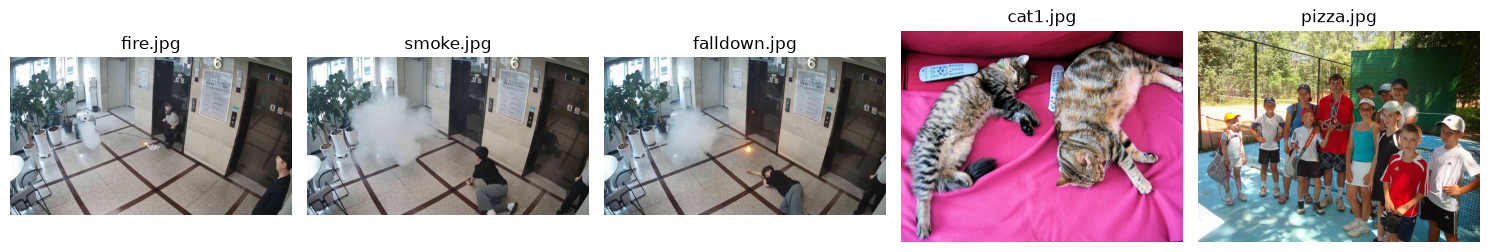

In [2]:
paths = [f"images/{n}.jpg" for n in ["fire","smoke","falldown","cat1","pizza"] if os.path.exists(f"images/{n}.jpg")]
fig, ax = plt.subplots(1, len(paths), figsize=(3*len(paths), 3))
for a, p in zip(np.atleast_1d(ax), paths):
    a.imshow(Image.open(p).convert("RGB")); a.set_title(os.path.basename(p)); a.axis("off")
plt.tight_layout(); plt.show()

## 2. 텍스트 프롬프트를 직접 입력 → 인코딩 → 분류\n원하는 문장을 그대로 넣으면 PE 텍스트 인코더가 즉석 인코딩한다.

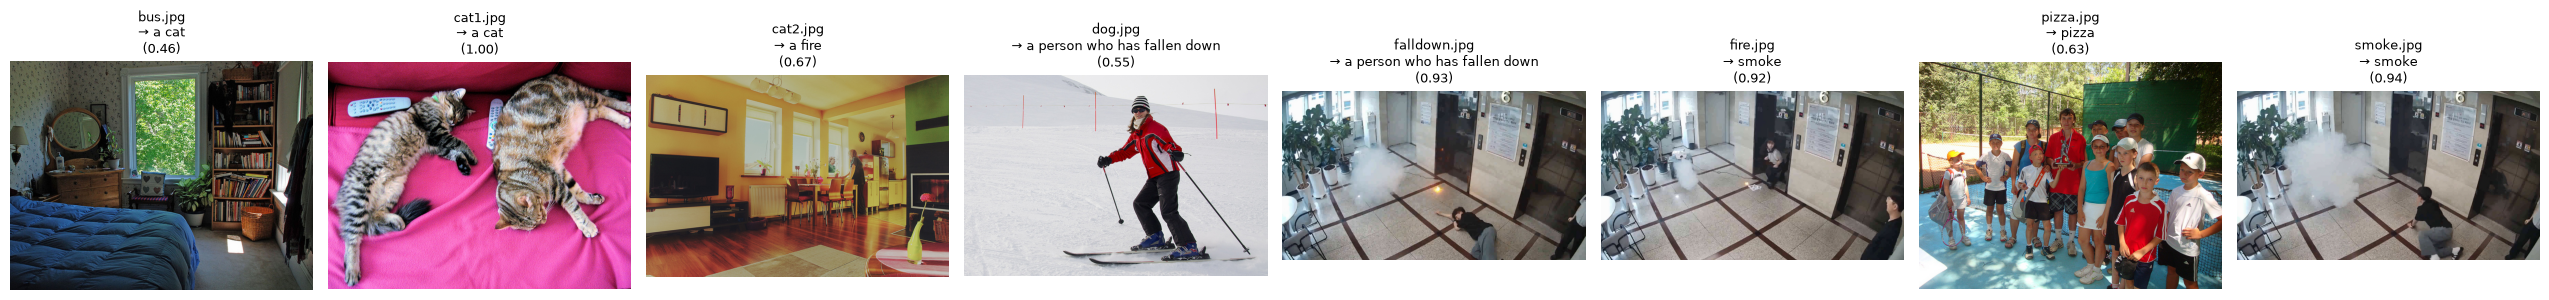

이미지(NPU) × 텍스트(즉석 인코딩) 유사도로 분류 = CLIP 제로샷


In [6]:
prompts = ["a fire", "smoke", "a person who has fallen down", "a normal street scene", "a cat", "pizza"]
txt = encode_text(prompts)                 # ← live 인코딩 (N,1024)
ls = clip.logit_scale.exp()

fig, axes = plt.subplots(1, len(paths), figsize=(3.2*len(paths), 3.4))
for a, p in zip(np.atleast_1d(axes), paths):
    sim = encode_image_npu(p) @ txt.T
    probs = (ls * sim).softmax(-1)
    pred = prompts[int(sim.argmax())]
    a.imshow(Image.open(p).convert("RGB")); a.axis("off")
    a.set_title(f"{os.path.basename(p)}\n→ {pred}\n({float(probs.max()):.2f})", fontsize=9)
plt.tight_layout(); plt.show()
print("이미지(NPU) × 텍스트(즉석 인코딩) 유사도로 분류 = CLIP 제로샷")

## 3. 직접 프롬프트 바꿔보기 (함수)

In [4]:
def classify(image_path, prompts):
    txt = encode_text(prompts)
    sim = encode_image_npu(image_path) @ txt.T
    probs = (clip.logit_scale.exp() * sim).softmax(-1)
    order = sim.argsort(descending=True)
    print(f"[{os.path.basename(image_path)}]")
    for i in order:
        print(f"  {float(probs[i]):.3f}  {prompts[int(i)]}")
    return prompts[int(sim.argmax())]

# 예: 원하는 문장 아무거나
classify("images/falldown.jpg", ["someone lying on the floor", "people walking", "a fire breaking out"])

[falldown.jpg]
  0.985  someone lying on the floor
  0.015  a fire breaking out
  0.000  people walking


'someone lying on the floor'